In [1]:
# Import
import os
import pandas as pd
import numpy as np

from pathlib import Path

from CellPacking.tissuegeneration import sheet_init, symetric_circular
from CellPacking.dynamics import (Compression, 
                                  AnisotropicLineTension, 
                                  ShearPlanarGeometry, 
                                  PlaneBarrierElasticity)

from tyssue import Sheet
from tyssue import PlanarGeometry
from tyssue.solvers import QSSolver
from tyssue.solvers.viscous import EulerSolver
from tyssue.behaviors.event_manager import EventManager
from tyssue.core.history import HistoryHdf5 


import matplotlib.pyplot as plt
from tyssue.draw import sheet_view
from CellPacking.plot import superimpose_sheet_view
from CellPacking.plot import sheet_view as ply_sheet_view

from tyssue.generation import extrude 
from tyssue import Monolayer
from CellPacking.dynamics import ShearMonolayerGeometry
from tyssue.io.hdf5 import save_datasets

from tyssue.io.hdf5 import load_datasets
from tyssue.io.meshes import save_triangular_mesh

CGAL-based mesh generation utilities not found, you may need to install CGAL and build from source
C++ extensions are not available for this version
collision solver could not be imported You may need to install CGAL and re-install tyssue


In [3]:
SIM_DIR = Path('/mnt/sda1/Sophie/1-CellPacking/20221015_3D_QS_without_HI(KEEP_SimuPrincipal)/')
sim_save_dir = SIM_DIR
try:
    os.mkdir(sim_save_dir)
except FileExistsError:
    pass

In [ ]:
%pdb

# Apical sheet init

In [ ]:
def tissue_init(phi, noise):
    
    apical_sheet, border = symetric_circular(10, -100, phi, 0,  noise=noise)

    apical_sheet.face_df['prefered_perimeter'] = 3 * np.sqrt(apical_sheet.face_df['prefered_area'])

    ## apical surface at the equilibrium
    # Solver
    solver_qs = QSSolver(with_t1=False, with_t3=False, with_collisions=False)

    manager = EventManager()
    manager.append(reconnect)
    # Model
    model = model_factory(
        [
            effectors.FaceAreaElasticity,
            effectors.PerimeterElasticity, 
        ])
    for i in range(50):
        manager.execute(apical_sheet)
        res = solver_qs.find_energy_min(apical_sheet, PlanarGeometry, model, periodic=False, options={"gtol": 1e-8})
        if res.success is False:
            print (i, res.success)
        apical_sheet.vert_df[["x", "y"]] += np.random.normal(scale=1e-3, size=(apical_sheet.Nv, 2))
        PlanarGeometry.update_all(apical_sheet)
        manager.update()


    ## Monolayer creation
    apical_sheet.face_df['z'] = 1
    apical_sheet.edge_df['z'] = 1
    apical_sheet.vert_df['z'] = 1

    extruded = extrude(apical_sheet.datasets, method='translation', vector=[0, 0, -2])
    monolayer = Monolayer('mono', extruded)

    monolayer.sanitize(trim_borders=True, order_edges=True)
    monolayer.validate()


    monolayer.face_df['prefered_area'] = monolayer.face_df.loc[0,'prefered_area']
    monolayer.face_df['prefered_perimeter'] = 3*np.sqrt(monolayer.face_df['prefered_area'])
    monolayer.face_df['area_elasticity'] = 1
    monolayer.face_df['perimeter_elasticity'] = 0.5


    

    monolayer.vert_df['barrier_elasticity'] = 280
    monolayer.vert_df['z_barrier'] = 0.6

    monolayer.update_specs({"settings":{"dt":0.01,
                                         'threshold_length': 0.1,
                                         'p_4': 1,
                                         'p_5p': 1,
                                          "nrj_norm_factor": 1.0, 
                                       'multiplier':3, },
                          "cell": {
                                    "x": 0.0,
                                    "y": 0.0,
                                    "z": 0.0,
                                    "is_alive": True,
                                    "prefered_volume": 0.7,
                                    "volume": 0.7,
                                    "volume_elasticity": 0.5,
                                    "z_barrier":1.1,
                                    },
                          "edge": {
                                    "dx": 0.0,
                                    "srce": 0,
                                    "face": 0,
                                    "dy": 0.0,
                                    "ny": 0.0,
                                    "nx": 0.0,
                                    "length": 0.0,
                                    "nz": 0.0,
                                    "cell": 0,
                                    "sub_volume": 0.0,
                                    "dz": 0.0,
                                    "sub_area": 0.0,
                                    "trgt": 0},
                          "vert": {
                                    "x": 0.0,
                                    "is_active": True,
                                    "z": 0.0,
                                    "y": 0.0},
                          "face": {
                                    "x": 0.0,
                                    "is_alive": True,
                                    "z": 0.0,
                                    "y": 0.0,}
                        })


    ShearMonolayerGeometry.update_all(monolayer)

    monolayer.face_df['prefered_area'] = monolayer.face_df['area']
    monolayer.face_df['prefered_perimeter'] = 3*np.sqrt(monolayer.face_df['prefered_area'])

    ShearMonolayerGeometry.update_all(monolayer)

    # Manager
    manager = EventManager('face')#, track_event=False)

    monolayer.get_opposite_faces()

    monolayer.get_opposite_faces()
    edge_opp_face = monolayer.upcast_face(monolayer.face_df['opposite'])
    monolayer.edge_df['is_border']=False
    monolayer.edge_df.loc[edge_opp_face[edge_opp_face==-1].index, 'is_border']=True

    monolayer.edge_df['opposite'] = pd.to_numeric(monolayer.edge_df['opposite'])
    monolayer.edge_df['z'] = pd.to_numeric(monolayer.edge_df['z'])

    ShearMonolayerGeometry.update_all(monolayer)

    # monolayer equilibrium before apply forces 
    # Model
    model = model_factory(
        [
            effectors.FaceAreaElasticity,
            effectors.PerimeterElasticity,
            effectors.CellVolumeElasticity,
        ],
    )
    manager.append(reconnect_3D)
    solver_qs = QSSolver(with_t1=False, with_t3=False, with_collisions=False)

    for i in range(10):
        manager.execute(monolayer)

        res = solver_qs.find_energy_min(monolayer, ShearMonolayerGeometry, model, periodic=False, options={"gtol": 1e-8})
        if res.success is False:
            print (i, res.success)
        monolayer.vert_df[["x", "y"]] += np.random.normal(scale=1e-3, size=(monolayer.Nv, 2))
        ShearMonolayerGeometry.update_all(monolayer)
        manager.update()


    return monolayer


def simu_process(monolayer_, r, g):
    
    monolayer=monolayer_.copy(deep_copy=True)
    sim_save_dir = SIM_DIR/str(r)
    try:
        os.mkdir(sim_save_dir)
    except FileExistsError:
        pass
    
    try:
        os.mkdir(sim_save_dir/str(g))
    except FileExistsError:
        pass

    gamma_0 = g
    monolayer.update_specs({"edge": {"gamma_0": g}})
    monolayer.edge_df['gamma_0'] = pd.to_numeric(monolayer.edge_df['gamma_0'])
    monolayer.edge_df['gamma_0'] = monolayer.edge_df['gamma_0'].replace(-100, g)
    
    monolayer.specs['settings']['file_text'] = os.path.join(sim_save_dir/str(g),'output_t1.txt')
    
    ## Apply forces
    # Model

    model = model_factory(
        [
            effectors.LineTension,
            effectors.FaceAreaElasticity,
            effectors.PerimeterElasticity,
            effectors.CellVolumeElasticity,
        ],
    )

    solver_qs = QSSolver(with_t1=False, with_t3=False, with_collisions=False)
    # Manager
    manager = EventManager('face')#, track_event=False)
    manager.append(reconnect_3D)

    for i in range(200):
        print('------------TEMPS------------')
        print(i)
        manager.execute(monolayer)

        res = solver_qs.find_energy_min(monolayer, ShearMonolayerGeometry, model, periodic=False, options={"gtol": 1e-8})
        if res.success is False:
            print (i, res.success)

        monolayer.vert_df[["x", "y"]] += np.random.normal(scale=1e-3, size=(monolayer.Nv, 2))
        manager.update()
        save_datasets(os.path.join(sim_save_dir/str(g),'monolayer'+str(i)+'.hf5'), monolayer)

In [ ]:
from joblib import Parallel, delayed
import multiprocessing
from datetime import datetime


global_start=datetime.now()
print ("start : " + str(global_start))
num_cores = multiprocessing.cpu_count()


repeat = np.arange(10)
gammas = np.linspace(0, 0.2, 21)

# Number of cells in x and y axis
nx = 40
ny = 40
noise = 0.3
phi = np.pi/2

for r in repeat[2:]:
    monolayer = tissue_init(phi, noise)
    
    results = Parallel(n_jobs=6)(delayed(simu_process)(
        monolayer, r, g) for g in gammas)

# simu_process(repeat[0][0], gammas[0][0], phi, noise)
global_end = datetime.now()
print ("end : " + str(global_end))
print ('Duree totale d execution : \n\t\t')
print (global_end-global_start)

In [ ]:
import time
from plyer import notification
notification.notify(
    title = "ALERT!!!",
    message = "It is finish",
    timeout=10
)

In [ ]:
monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer199.hf5'))
monolayer = Monolayer("mono", monolayer_d)
np.mean(monolayer.edge_df[((monolayer.edge_df['segment']=="apical") | (monolayer.edge_df['segment']=="basal")) &
                         (monolayer.edge_df.length>0.1)]['length'])

In [ ]:
length

# Analyse

In [ ]:

result = pd.DataFrame(columns = ['repeat', 'gamma', 'nb_change', 'tot_cell'])

repeat = np.arange(10)
gammas = np.linspace(0, 0.2, 21)
# gammas = np.linspace(0.19, 0.19, 1)
length = []
for r in repeat:
    sim_save_dir = SIM_DIR/str(r)   
    for g in gammas:
        dir_ = sim_save_dir/str(g)
        try : 
            monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer199.hf5'))
        except: 
            monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer99.hf5'))
        monolayer = Monolayer("mono", monolayer_d)
        count = len(np.unique(monolayer.edge_df[(monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['num_sides']==3].index)) &
                  (monolayer.edge_df['segment']=='lateral') & (monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['area']>0.01].index))]['cell']))
        
        result = pd.concat([result, pd.DataFrame({'repeat':r,
                                                  'gamma':g, 
                                                  'nb_change':count,
                                                 'tot_cell': monolayer.Nc},
                          index=[0])],
                          ignore_index=True)
        
#         save_triangular_mesh('monolayer'+str(g)+'.vtk', monolayer)
        length.append(np.mean(monolayer.edge_df[((monolayer.edge_df['segment']=="apical") | (monolayer.edge_df['segment']=="basal")) &
                         (monolayer.edge_df.length>0.1)]['length']))
        
result['pourcentage'] = result['nb_change']/result['tot_cell']*100

In [ ]:
result.to_csv(os.path.join(SIM_DIR, 'result_pourcentage_min.csv'))

In [ ]:
result['pourcentage'] = result['pourcentage']-np.min(result['pourcentage'])

In [ ]:
fig, ax = plt.subplots()
ax.plot(result['gamma'], result['pourcentage'], '.', markersize=10, color='black')
ax.set_xlabel('gamma')
ax.set_ylabel('% of cell that have neighbouring change')

ax.plot(result.groupby('gamma').mean().index, result.groupby('gamma').mean()['pourcentage'], 
        '.',color='red',  markersize=10, label='mean')
# fig.set_label()
fig.set_size_inches((10,10))

fig.savefig(SIM_DIR/'result_basal.png', dpi=150)

In [ ]:
fig, ax = plt.subplots()
# ax.plot(result['gamma'], result['pourcentage'], '.', markersize=10, color='black')
ax.set_xlabel('gamma')
ax.set_ylabel('% of cell that have neighbouring change')

ax.plot(result.groupby('gamma').mean().index, result.groupby('gamma').mean()['pourcentage'], 
        '.',color='red',  markersize=10, label='mean')


ax.errorbar(result.groupby('gamma').mean().index,
            result.groupby('gamma').mean()['pourcentage'],
            result.groupby('gamma').std()['pourcentage'],
            linestyle='None', fmt='-o', color='red')
fig.set_size_inches((10,10))

# fig.savefig(SIM_DIR/'result.eps', dpi=300)

In [ ]:
result.to_csv(os.path.join(SIM_DIR, 'result_count.csv'))

In [ ]:
from tyssue.io.meshes import save_triangular_mesh
save_triangular_mesh('monolayer.vtk', monolayer)

# Result V2

In [4]:

result_t1_angle = pd.DataFrame(columns = ['repeat', 'gamma', 'angle'])

repeat = np.arange(10)
gammas = np.linspace(0, 0.2, 21)
# gammas = np.linspace(0.19, 0.19, 1)

for r in repeat:
    sim_save_dir = SIM_DIR/str(r)   
    for g in gammas:
        dir_ = sim_save_dir/str(g)
        try : 
            
            t1_angle = pd.read_csv(os.path.join(dir_,'output_t1.txt'), header=None, sep="\t")
            t1_angle.columns = ['edge_id', 'area', 'angle']
            t1_angle["angle_0_pi"] = [np.pi+a if a<0 else a for a in t1_angle['angle']]
            t1_angle_filter = t1_angle[t1_angle["area"]>0.1]["angle_0_pi"]
            
            result_t1_angle = pd.concat([result_t1_angle, pd.DataFrame({'repeat':r,
                                                      'gamma':g, 
                                                      'angle':t1_angle_filter,
                                                     })],
                          ignore_index=True)
        
        except: 
            pass
        

In [ ]:
# result_t1_angle.to_csv(os.path.join(SIM_DIR, 'result_t1_angle.csv'))

(array([ 76.,  98.,  90.,  91., 103.,  99.,  96.,  82.,  68.,  95., 103.,
        109., 102.,  78.,  82.,  92.,  84., 122.]),
 array([2.04069659e-03, 1.76321308e-01, 3.50601920e-01, 5.24882532e-01,
        6.99163144e-01, 8.73443756e-01, 1.04772437e+00, 1.22200498e+00,
        1.39628559e+00, 1.57056620e+00, 1.74484682e+00, 1.91912743e+00,
        2.09340804e+00, 2.26768865e+00, 2.44196926e+00, 2.61624988e+00,
        2.79053049e+00, 2.96481110e+00, 3.13909171e+00]),
 <BarContainer object of 18 artists>)

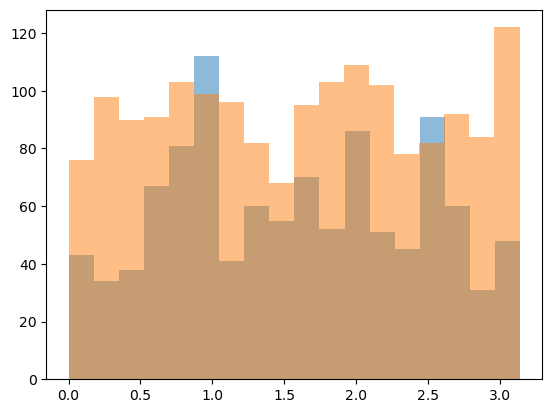

In [5]:
plt.hist(result_t1_angle[result_t1_angle["gamma"]==0]['angle'], bins=18,alpha=0.5, density=False)
plt.hist(result_t1_angle[result_t1_angle["gamma"]==0.2]['angle'], bins=18, alpha=0.5, density=False)

In [ ]:
b=18
for repeat in range (2, 10):
    fig = plt.figure()
    polar_ax = fig.add_subplot(1, 1, 1, projection="polar")

    # bin data for our polar histogram
    counts0_, bin_0 = np.histogram(result_t1_angle[(result_t1_angle["gamma"]==0) & (result_t1_angle["repeat"]==repeat)]['angle'], bins=b, range=(0,np.pi), density=False)
    counts0=counts0_/np.sum(counts0_)*100
    polar_ax.bar((bin_0[:-1]+bin_0[1]/2), counts0, width=np.pi/b, alpha=0.5, label='0')

    counts_, bin_ = np.histogram(result_t1_angle[(result_t1_angle["gamma"]==0.2) & (result_t1_angle["repeat"]==repeat)]['angle'], bins=b, range=(0,np.pi), density=False)
    counts = counts_/np.sum(counts_)*100
    polar_ax.bar((bin_[:-1]+bin_[1]/2), counts, width=np.pi/b, alpha=0.5, label='0.2')

    print(np.sum(counts0_), np.sum(counts_))
    fig.legend()
    fig.set_size_inches((10,10))
    fig.savefig(str(SIM_DIR/'angle_new_junction')+str(repeat)+'.png', dpi=150)

1065 1670


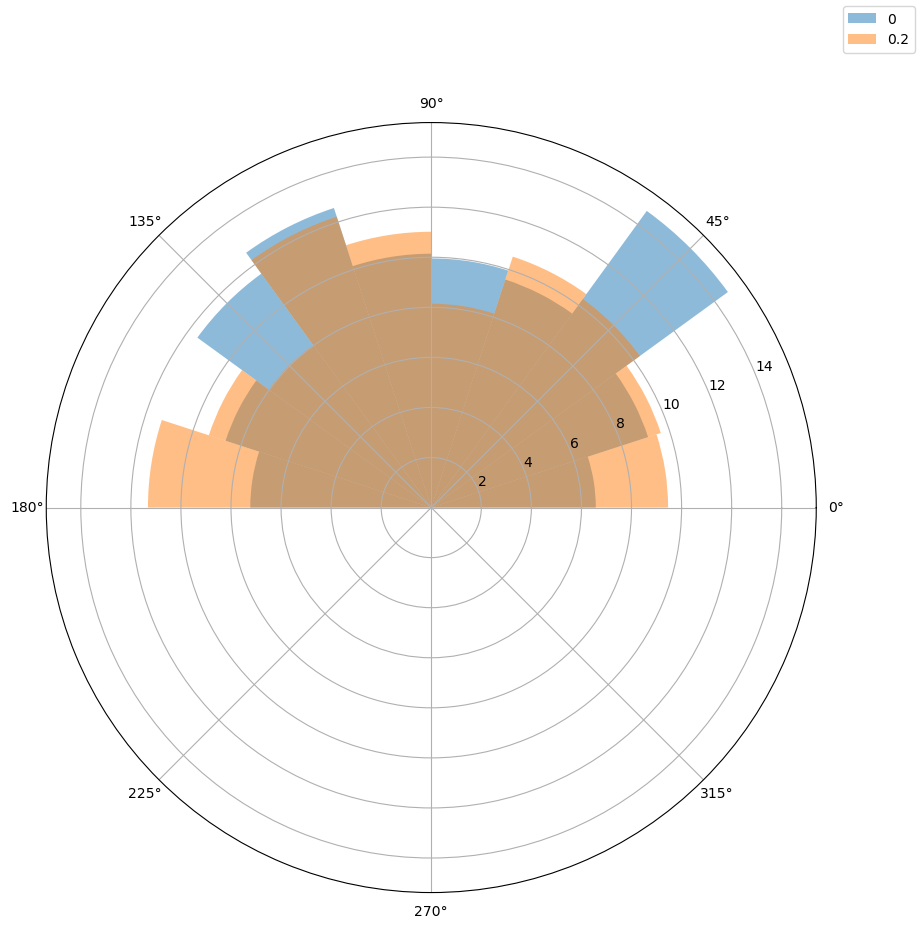

In [6]:
fig = plt.figure()
polar_ax = fig.add_subplot(1, 1, 1, projection="polar")

b=10

# bin data for our polar histogram
counts0_, bin_0 = np.histogram(result_t1_angle[(result_t1_angle["gamma"]==0)]['angle'], bins=b, range=(0,np.pi), density=False)
counts0=counts0_/np.sum(counts0_)*100
polar_ax.bar((bin_0[:-1]+bin_0[1]/2), counts0, width=np.pi/b, alpha=0.5, label='0')

counts_, bin_ = np.histogram(result_t1_angle[(result_t1_angle["gamma"]==0.2)]['angle'], bins=b, range=(0,np.pi), density=False)
counts = counts_/np.sum(counts_)*100
polar_ax.bar((bin_[:-1]+bin_[1]/2), counts, width=np.pi/b, alpha=0.5, label='0.2')

print(np.sum(counts0_), np.sum(counts_))
fig.legend()
fig.set_size_inches((10,10))
# fig.savefig(SIM_DIR/'angle_new_junction.png', dpi=150)

# Result V3 - tenseur

In [7]:
from scipy.linalg import eig, inv

result = pd.DataFrame(columns = ['repeat', 'gamma', 'T_i', 'eigen'])

repeat = np.arange(10)
gammas = np.linspace(0, 0.2, 21)

for r in repeat:
    sim_save_dir = SIM_DIR/str(r)   
    for g in gammas:
        dir_ = sim_save_dir/str(g)
        try : 
            monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer199.hf5'))
        except: 
            monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer99.hf5'))
        monolayer = Monolayer("mono", monolayer_d)
        id_new_edges = monolayer.edge_df[(monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['num_sides']==3].index)) 
                                                 & (monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['area']>0.01].index))
                                                 &   (((monolayer.edge_df['sz']>0.4) & (monolayer.edge_df['tz']>0.4)) |
                                                     ((monolayer.edge_df['sz']<-0.4) & (monolayer.edge_df['tz']<-0.4))) 
                                                 ].index

        # Pour chaque edge apical (ou basal) d'une face triangulaire

        mm_apical = []
        mm_basal = []
        for id_ in id_new_edges:
            # Recuperation des faces voisines
            id_face_neighbours = monolayer.get_neighbors(monolayer.edge_df.loc[id_]['face'], elem='face')
            neighbouring_face = monolayer.face_df.loc[list(id_face_neighbours)]

            # recuperation des faces uniquement apicale(ou basale)
            faces = []
            segment = ""
            for nf in neighbouring_face.index : 
                if ((monolayer.edge_df[monolayer.edge_df['face']==nf]['sz'] >  0.2).all() & (monolayer.edge_df[monolayer.edge_df['face']==nf]['tz'] >  0.2).all()):
                    if monolayer.face_df.loc[nf]['opposite']==-1:
                        faces.append(nf)
                        segment = "apical"
                elif ((monolayer.edge_df[monolayer.edge_df['face']==nf]['sz'] < -0.2).all() & (monolayer.edge_df[monolayer.edge_df['face']==nf]['tz'] < -0.2).all()):
                    if monolayer.face_df.loc[nf]['opposite']==-1:
                        faces.append(nf)
                        segment = 'basal'

            if len(faces)==2:
                # Creation de la matrice m
                X, Y, Z = monolayer.face_df.loc[faces[0]][list("xyz")] - monolayer.face_df.loc[faces[1]][list("xyz")]


                m = np.array([[X**2,  X*Y , X*Z ],
                              [Y*X  , Y**2, Y*Z ],
                              [Z*X  , Z*Y , Z**2]
                            ])
                m = m[:2,:2]
                if segment == 'apical':
                    mm_apical.append(m)
                elif segment == 'basal':
                    mm_basal.append(m)
                    
        mm_apical = np.array(mm_apical)
        mm_basal  = np.array(mm_basal)
        T_i = mm_apical.shape[0] * mm_apical.mean(axis=0) - mm_basal.shape[0] * mm_basal.mean(axis=0)
        
        
        #Eigen value calculation
        # Diagonalisation
        vals, vecs = eig(T_i)
        diag_m = np.zeros((2, 2))
        for i in range(0,len(vals)):
            diag_m[i,i] = vals[i].real
       
        
        result = pd.concat([result, pd.DataFrame({'repeat':r,
                                                  'gamma':g, 
                                                  'T_i':[T_i],
                                                  'eigen':[diag_m]})],
                          ignore_index=True)

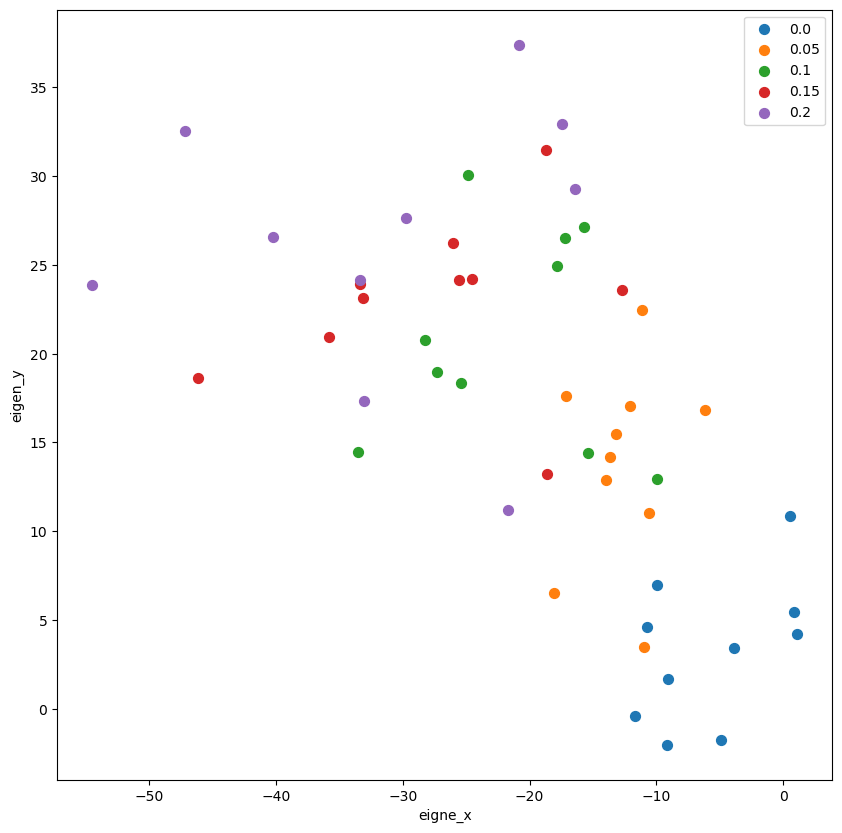

In [9]:
# Plot 
eigen_x = []
eigen_y = []
for i in range(result.shape[0]):
    eigen_x.append(np.min((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))
    eigen_y.append(np.max((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))
#     eigen_x.append(result.iloc[i]['eigen'][0,0])
#     eigen_y.append(result.iloc[i]['eigen'][1,1])

fig, ax = plt.subplots()
fig.set_size_inches((10,10))
i=0
for g in gammas[::5]:
    ax.scatter(eigen_x[i::21], eigen_y[i::21], s=50, label=g)
    i+=5
ax.set_xlabel('eigne_x')
ax.set_ylabel('eigen_y')
ax.legend()

Text(0, 0.5, 'eigen_x')

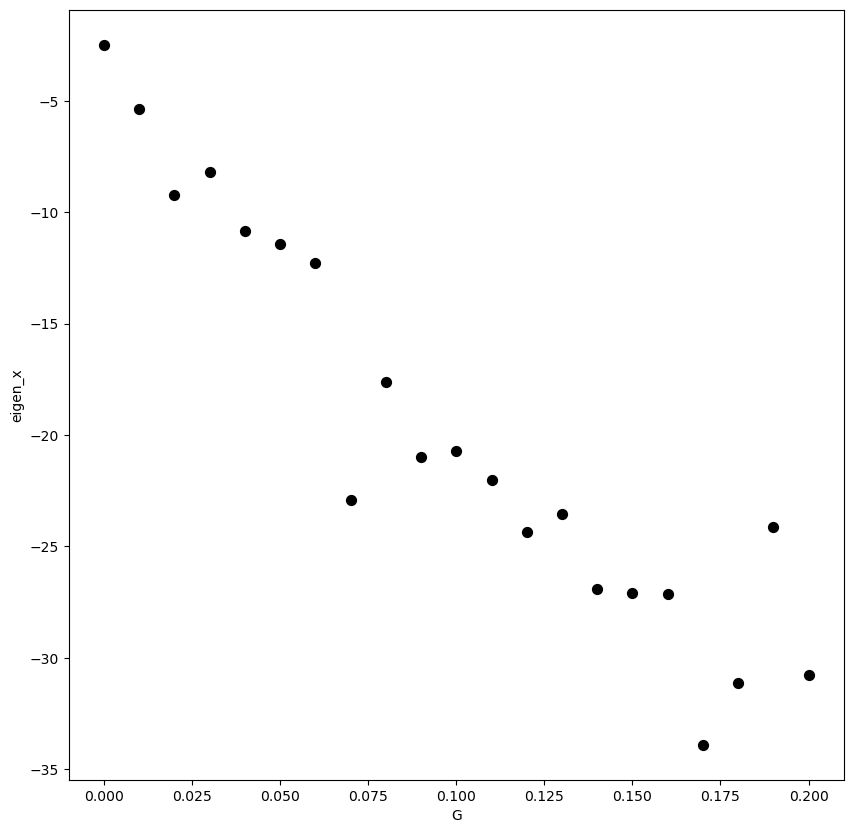

In [10]:
# Matrice T sommée sur tous les réplicats
result_sum = result.groupby("gamma").sum()[['T_i']]/10
result_sum['eigen'] = np.repeat("", result_sum.shape[0])

# Recalcul des valeurs propres sur la somme des T_i (=> Lambda_X(<T_i>))
for id_, val in result_sum.iterrows():
    vals, vecs = eig(val['T_i'])
    diag_m = np.zeros((2,2))
    for i in range(0,len(vals)):
        diag_m[i,i] = vals[i].real
    result_sum.loc[id_]['eigen'] = diag_m

    

# plot
fig, ax = plt.subplots()
fig.set_size_inches((10,10))
for id_, val in result_sum.iterrows():
    ax.scatter(id_, val['eigen'][0, 0], color='black', s=50)

ax.set_xlabel('G')
ax.set_ylabel('eigen_x')


# fig.savefig(SIM_DIR/'gamma_eigenX.png', dpi=150)


In [11]:
# Bootstrap pour calculer l'intervalle de confiance
eigen_x = []
eigen_y = []
for i in range(result.shape[0]):
    eigen_x.append(np.min((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))

from scipy.stats import bootstrap

result_bootstrap = pd.DataFrame(columns= ['G', 'ci_l', 'ci_h', 'std_error'])
i=0
for g in gammas:
    res = bootstrap((eigen_x[i::21],), 
                    np.std, 
                    confidence_level=0.95, 
                    random_state=1,
                    method="percentile", 
                   )
    
    result_bootstrap = pd.concat([result_bootstrap, 
                                  pd.DataFrame.from_dict({'G':g, 
                                                'ci_l':res.confidence_interval[0],
                                                'ci_h':res.confidence_interval[1],
                                                'std_error':res.standard_error,
                                               }, orient='index').T],
                          ignore_index=True)
    i+=1

<Axes: xlabel='G'>

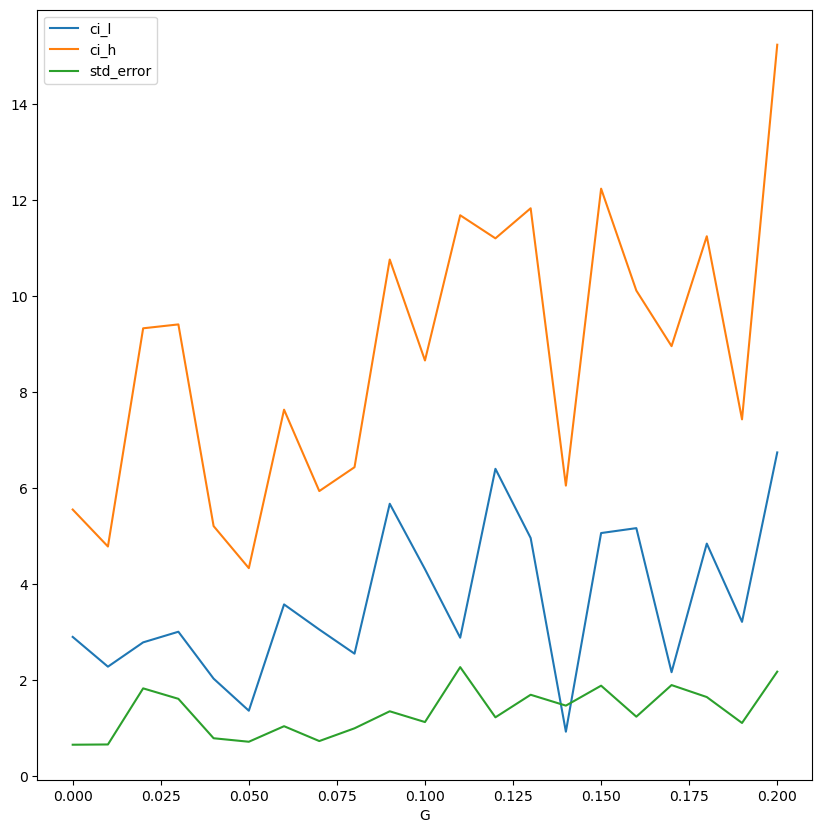

In [12]:
fig, ax = plt.subplots()
fig.set_size_inches((10,10))
result_bootstrap.plot('G', ['ci_l', 'ci_h', 'std_error'], ax=ax)
# fig.savefig(SIM_DIR/'result_bootstrap.png', dpi=150)

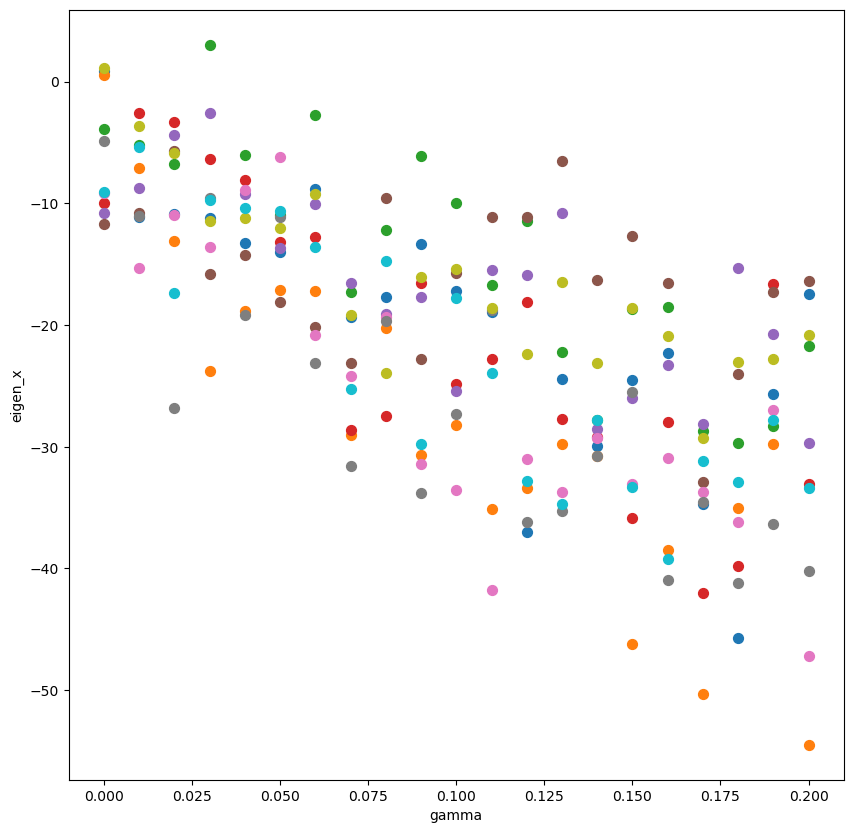

In [13]:
fig, ax = plt.subplots()
i=0
for r in repeat:
    st = i*21
    ax.scatter(gammas, eigen_x[st:st+21:],s=50)
    i+=1
ax.set_ylabel('eigen_x')
ax.set_xlabel('gamma')
fig.set_size_inches((10,10))


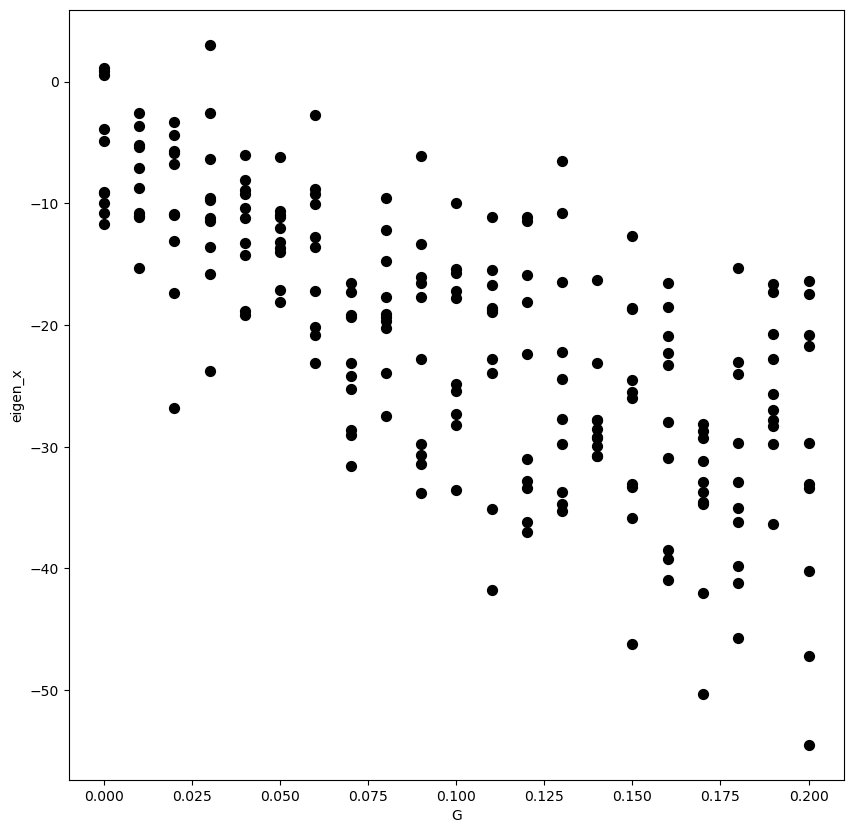

In [14]:
fig, ax = plt.subplots()
i=0
for g in gammas:
    ax.scatter(np.repeat(g,10), eigen_x[i::21], s=50, color='black')
    i+=1
ax.set_ylabel('eigen_x')
ax.set_xlabel('G')
fig.set_size_inches((10,10))
fig.savefig(SIM_DIR/'gamma_eigenX_replicats.png', dpi=150)


# fig, ax = plt.subplots()
# i=0
# for g in gammas:
#     ax.plot(np.repeat(g,10), eigen_y[i::21], '.', color='black')
#     i+=1
# ax.set_xlabel('gamma')
# ax.set_ylabel('eigen_y')

In [ ]:
result.to_csv(SIM_DIR/"result_ti.csv")
result_sum.to_csv(SIM_DIR/"result_t_sum.csv")
result_bootstrap.to_csv(SIM_DIR/"result_bootstrap.csv")

In [15]:
eigen_x = []
eigen_y = []
for i in range(result.shape[0]):
    eigen_x.append(np.min((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))
    eigen_y.append(np.max((result.iloc[i]['eigen'][0,0], result.iloc[i]['eigen'][1,1])))
    
result['Lambda_x'] = eigen_x
result['Lambda_y'] = eigen_y
result

,repeat,gamma,T_i,eigen,Lambda_x,Lambda_y
0,0,0.00,"[[2.8267573628368368, 2.2835455774283333], [2....","[[0.8412322399055032, 0.0], [0.0, 5.4530552343...",0.841232,5.453055
1,0,0.01,"[[-10.946975616188418, 1.5734146221097718], [1...","[[-11.126345036715144, 0.0], [0.0, 2.854895214...",-11.126345,2.854895
2,0,0.02,"[[-10.484279360847694, 1.9733258854200226], [1...","[[-10.841494534125124, 0.0], [0.0, 0.416755481...",-10.841495,0.416755
3,0,0.03,"[[-10.691607367324629, 2.9216862546048685], [2...","[[-11.172823565689589, 0.0], [0.0, 7.047302086...",-11.172824,7.047302
4,0,0.04,"[[-13.190120538039613, 0.6568362677450728], [0...","[[-13.228569579451415, 0.0], [0.0, -1.96919364...",-13.228570,-1.969194
...,...,...,...,...,...,...
205,9,0.16,"[[-39.17188377094668, -2.557727520353964], [-2...","[[-39.25641520910381, 0.0], [0.0, 38.219087103...",-39.256415,38.219087
206,9,0.17,"[[-31.131270492407406, -1.0794459142030177], [...","[[-31.146763375744555, 0.0], [0.0, 44.07767908...",-31.146763,44.077679
207,9,0.18,"[[-31.108615912238697, -10.678652553244035], [...","[[-32.92361674850604, 0.0], [0.0, 31.719796105...",-32.923617,31.719796
208,9,0.19,"[[-27.72240572332816, -2.012641269938336], [-2...","[[-27.791883177023983, 0.0], [0.0, 30.58031934...",-27.791883,30.580319


In [16]:


eigen_x = []
eigen_y = []
for i in range(result_sum.shape[0]):
    eigen_x.append(np.min((result_sum.iloc[i]['eigen'][0,0], result_sum.iloc[i]['eigen'][1,1])))
    eigen_y.append(np.max((result_sum.iloc[i]['eigen'][0,0], result_sum.iloc[i]['eigen'][1,1])))
    
result_sum['Lambda_x'] = eigen_x
result_sum['Lambda_y'] = eigen_y
result_sum

,T_i,eigen,Lambda_x,Lambda_y
gamma,,,,
0.00,"[[-1.6734957211402537, 1.1829687739787853], [1...","[[-2.475384712055196, 0.0], [0.0, 0.0716524677...",-2.475385,0.071652
0.01,"[[-5.1927867529894325, 1.1211960975591617], [1...","[[-5.351203171432953, 0.0], [0.0, 2.7425062016...",-5.351203,2.742506
0.02,"[[-9.164850636572023, -0.6397708087168509], [-...","[[-9.200319811162, 0.0], [0.0, 2.3749354570655...",-9.200320,2.374935
0.03,"[[-8.098921787590168, 1.0070737575083892], [1....","[[-8.179008528303978, 0.0], [0.0, 4.5648168540...",-8.179009,4.564817
0.04,"[[-10.83492104500002, -0.4358055026558073], [-...","[[-10.847792624361796, 0.0], [0.0, 3.920567058...",-10.847793,3.920567
0.05,"[[-11.24441891150523, -1.993558379423081], [-1...","[[-11.411911771538561, 0.0], [0.0, 12.48360753...",-11.411912,12.483608
0.06,"[[-12.209360756902473, 1.0929386512376253], [1...","[[-12.255389482104238, 0.0], [0.0, 13.74214865...",-12.255389,13.742149
0.07,"[[-22.569145049039534, -3.2765181538594677], [...","[[-22.895032216197592, 0.0], [0.0, 10.37345685...",-22.895032,10.373457
0.08,"[[-17.608936742374237, -1.015084011210842], [-...","[[-17.640169924784658, 0.0], [0.0, 15.38147506...",-17.640170,15.381475


In [20]:
result = result.drop(["P","trace"], axis=1)

,repeat,gamma,T_i,eigen,Lambda_x,Lambda_y
0,0,0.00,"[[2.8267573628368368, 2.2835455774283333], [2....","[[0.8412322399055032, 0.0], [0.0, 5.4530552343...",0.841232,5.453055
1,0,0.01,"[[-10.946975616188418, 1.5734146221097718], [1...","[[-11.126345036715144, 0.0], [0.0, 2.854895214...",-11.126345,2.854895
2,0,0.02,"[[-10.484279360847694, 1.9733258854200226], [1...","[[-10.841494534125124, 0.0], [0.0, 0.416755481...",-10.841495,0.416755
3,0,0.03,"[[-10.691607367324629, 2.9216862546048685], [2...","[[-11.172823565689589, 0.0], [0.0, 7.047302086...",-11.172824,7.047302
4,0,0.04,"[[-13.190120538039613, 0.6568362677450728], [0...","[[-13.228569579451415, 0.0], [0.0, -1.96919364...",-13.228570,-1.969194
...,...,...,...,...,...,...
205,9,0.16,"[[-39.17188377094668, -2.557727520353964], [-2...","[[-39.25641520910381, 0.0], [0.0, 38.219087103...",-39.256415,38.219087
206,9,0.17,"[[-31.131270492407406, -1.0794459142030177], [...","[[-31.146763375744555, 0.0], [0.0, 44.07767908...",-31.146763,44.077679
207,9,0.18,"[[-31.108615912238697, -10.678652553244035], [...","[[-32.92361674850604, 0.0], [0.0, 31.719796105...",-32.923617,31.719796
208,9,0.19,"[[-27.72240572332816, -2.012641269938336], [-2...","[[-27.791883177023983, 0.0], [0.0, 30.58031934...",-27.791883,30.580319


In [28]:
result_sum = pd.read_csv(SIM_DIR/"result_ti.csv")
result_sum

,Unnamed: 0,repeat,gamma,T_i,eigen,Lambda_x,Lambda_y
0,0,0,0.00,[[2.82675736 2.28354558]\n [2.28354558 3.46753...,[[0.84123224 0. ]\n [0. 5.45305...,0.841232,5.453055
1,1,0,0.01,[[-10.94697562 1.57341462]\n [ 1.57341462 ...,[[-11.12634504 0. ]\n [ 0. ...,-11.126345,2.854895
2,2,0,0.02,[[-10.48427936 1.97332589]\n [ 1.97332589 ...,[[-10.84149453 0. ]\n [ 0. ...,-10.841495,0.416755
3,3,0,0.03,[[-10.69160737 2.92168625]\n [ 2.92168625 ...,[[-11.17282357 0. ]\n [ 0. ...,-11.172824,7.047302
4,4,0,0.04,[[-13.19012054 0.65683627]\n [ 0.65683627 ...,[[-13.22856958 0. ]\n [ 0. ...,-13.228570,-1.969194
...,...,...,...,...,...,...,...
205,205,9,0.16,[[-39.17188377 -2.55772752]\n [ -2.55772752 ...,[[-39.25641521 0. ]\n [ 0. ...,-39.256415,38.219087
206,206,9,0.17,[[-31.13127049 -1.07944591]\n [ -1.07944591 ...,[[-31.14676338 0. ]\n [ 0. ...,-31.146763,44.077679
207,207,9,0.18,[[-31.10861591 -10.67865255]\n [-10.67865255 ...,[[-32.92361675 0. ]\n [ 0. ...,-32.923617,31.719796
208,208,9,0.19,[[-27.72240572 -2.01264127]\n [ -2.01264127 ...,[[-27.79188318 0. ]\n [ 0. ...,-27.791883,30.580319


In [29]:
result_sum2 = pd.read_csv(SIM_DIR/"result_SI.csv")
result_sum2

,Unnamed: 0,repeat,gamma,nb_change,tot_cell,pourcentage,P,trace
0,0,0,0.00,42,323,5.595689,1.427809,6.294287
1,1,0,0.01,41,323,5.286091,4.328557,-8.271450
2,2,0,0.02,43,323,5.905286,3.485526,-10.424739
3,3,0,0.03,38,323,4.357298,5.640906,-4.125521
4,4,0,0.04,43,323,5.905286,3.485875,-15.197763
...,...,...,...,...,...,...,...,...
205,205,9,0.16,97,324,22.530864,23.912192,-1.037328
206,206,9,0.17,92,324,20.987654,23.217421,12.930916
207,207,9,0.18,101,324,23.765432,19.951671,-1.203821
208,208,9,0.19,97,324,22.530864,18.016112,2.788436


In [35]:
result_final = result_sum.copy(deep=True)
result_final["tot_cell"] = result_sum2["tot_cell"]
result_final["pourcentage"] = result_sum2["pourcentage"]

In [36]:
#result from first analysis
# result_final = result.copy(deep=True)
result_final['P'] = ((result_sum['Lambda_y']-result_sum['Lambda_x'])/result_final['tot_cell']*100).to_numpy()
result_final.groupby("gamma").mean()

/tmp/ipykernel_157611/2442010093.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  result_final.groupby("gamma").mean()


,Unnamed: 0,repeat,Lambda_x,Lambda_y,tot_cell,pourcentage,P
gamma,,,,,,,
0.00,94.5,4.5,-5.697052,3.293320,324.4,5.310795,2.773182
0.01,95.5,4.5,-8.091951,5.483254,324.4,4.110326,4.181489
0.02,96.5,4.5,-10.510841,3.685456,324.4,6.202168,4.368361
0.03,97.5,4.5,-10.114160,6.499968,324.4,6.474459,5.119145
0.04,98.5,4.5,-11.929982,5.002757,324.4,7.716618,5.212809
0.05,99.5,4.5,-12.676037,13.747733,324.4,8.767628,8.144351
0.06,100.5,4.5,-13.849339,15.336098,324.4,9.625035,8.985566
0.07,101.5,4.5,-23.418067,10.896491,324.4,10.208795,10.584917
0.08,102.5,4.5,-18.401527,16.142832,324.4,12.585092,10.653481


/tmp/ipykernel_157611/1302576087.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax.scatter(result_final.groupby("gamma").mean()['pourcentage'], result_final.groupby("gamma").mean()['P'],s=50, color='red')
/tmp/ipykernel_157611/1302576087.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax.scatter(result_final.groupby("gamma").mean()['pourcentage'], result_final.groupby("gamma").mean()['P'],s=50, color='red')


Text(0, 0.5, 'P')

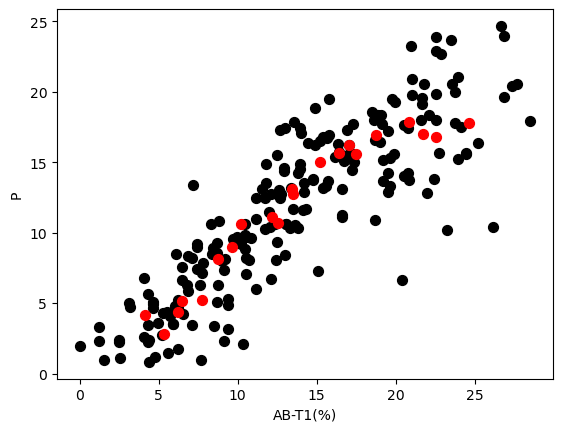

In [37]:
fig, ax = plt.subplots()
ax.scatter(result_final['pourcentage'], result_final['P'],s=50, color='black')
ax.scatter(result_final.groupby("gamma").mean()['pourcentage'], result_final.groupby("gamma").mean()['P'],s=50, color='red')
ax.set_xlabel("AB-T1(%)")
ax.set_ylabel("P")


In [38]:
group_pourcent = result_final.groupby('gamma').mean()['pourcentage']
result_final['trace'] = (result_sum['Lambda_y']+result_sum['Lambda_x']).to_numpy()
result_final

/tmp/ipykernel_157611/2908370252.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  group_pourcent = result_final.groupby('gamma').mean()['pourcentage']


,Unnamed: 0,repeat,gamma,T_i,eigen,Lambda_x,Lambda_y,tot_cell,pourcentage,P,trace
0,0,0,0.00,[[2.82675736 2.28354558]\n [2.28354558 3.46753...,[[0.84123224 0. ]\n [0. 5.45305...,0.841232,5.453055,323,5.595689,1.427809,6.294287
1,1,0,0.01,[[-10.94697562 1.57341462]\n [ 1.57341462 ...,[[-11.12634504 0. ]\n [ 0. ...,-11.126345,2.854895,323,5.286091,4.328557,-8.271450
2,2,0,0.02,[[-10.48427936 1.97332589]\n [ 1.97332589 ...,[[-10.84149453 0. ]\n [ 0. ...,-10.841495,0.416755,323,5.905286,3.485526,-10.424739
3,3,0,0.03,[[-10.69160737 2.92168625]\n [ 2.92168625 ...,[[-11.17282357 0. ]\n [ 0. ...,-11.172824,7.047302,323,4.357298,5.640906,-4.125521
4,4,0,0.04,[[-13.19012054 0.65683627]\n [ 0.65683627 ...,[[-13.22856958 0. ]\n [ 0. ...,-13.228570,-1.969194,323,5.905286,3.485875,-15.197763
...,...,...,...,...,...,...,...,...,...,...,...
205,205,9,0.16,[[-39.17188377 -2.55772752]\n [ -2.55772752 ...,[[-39.25641521 0. ]\n [ 0. ...,-39.256415,38.219087,324,22.530864,23.912192,-1.037328
206,206,9,0.17,[[-31.13127049 -1.07944591]\n [ -1.07944591 ...,[[-31.14676338 0. ]\n [ 0. ...,-31.146763,44.077679,324,20.987654,23.217421,12.930916
207,207,9,0.18,[[-31.10861591 -10.67865255]\n [-10.67865255 ...,[[-32.92361675 0. ]\n [ 0. ...,-32.923617,31.719796,324,23.765432,19.951671,-1.203821
208,208,9,0.19,[[-27.72240572 -2.01264127]\n [ -2.01264127 ...,[[-27.79188318 0. ]\n [ 0. ...,-27.791883,30.580319,324,22.530864,18.016112,2.788436


/tmp/ipykernel_157611/3226441459.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  result_final.groupby('gamma').mean()['trace'],s=50, color='red')


Text(0, 0.5, 'trace')

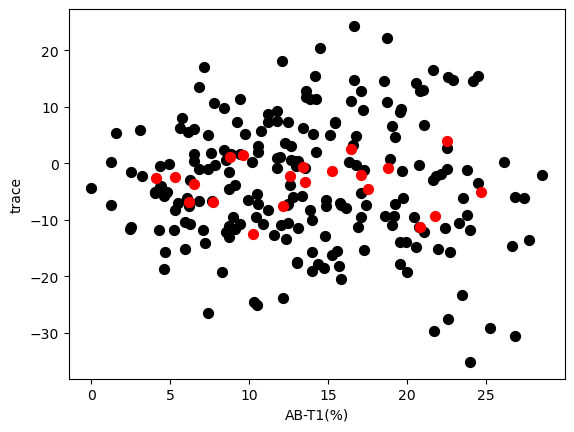

In [39]:
fig, ax = plt.subplots()
ax.scatter(result_final['pourcentage'], result_final['trace'],s=50, color='black')
ax.scatter(group_pourcent, 
           result_final.groupby('gamma').mean()['trace'],s=50, color='red')
ax.set_xlabel("AB-T1(%)")
ax.set_ylabel("trace")


In [ ]:
result_final.to_csv(SIM_DIR/"result_SI.csv")

In [ ]:
result_final

In [44]:
r = 0
g = 0.0
nb_changes = []

sim_save_dir = SIM_DIR/str(r)   
dir_ = sim_save_dir/str(g)
for i in range(200):
    monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer'+str(i)+'.hf5'))

    monolayer = Monolayer("mono", monolayer_d)
    count = len(np.unique(monolayer.edge_df[(monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['num_sides']==3].index)) &
                  (monolayer.edge_df['segment']=='lateral') & (monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['area']>0.01].index))]['cell']))
    nb_changes.append(count/monolayer.Nc*100)

    
    
tri_face_ids = np.unique(monolayer.edge_df[(monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['num_sides']==3].index)) &
                  (monolayer.edge_df['segment']=='lateral') & (monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['area']>0.01].index))]['cell'])

angle0=[]
for f in tri_face_ids :
    dx = monolayer.edge_df[(monolayer.edge_df['face']==f) & 
                    (((monolayer.edge_df['sz']>0.4) & (monolayer.edge_df['tz']>0.4)) |
                     ((monolayer.edge_df['sz']<-0.4) & (monolayer.edge_df['tz']<-0.4)))]['dx'].to_numpy()
    dy = monolayer.edge_df[(monolayer.edge_df['face']==f) & 
                    (((monolayer.edge_df['sz']>0.4) & (monolayer.edge_df['tz']>0.4)) |
                     ((monolayer.edge_df['sz']<-0.4) & (monolayer.edge_df['tz']<-0.4)))]['dy'].to_numpy()
    if len(dx)!=0:
        angle0.append(np.arctan2(dy, dx)[0]*180/np.pi)        
 



        
g = 0.2
nb_changes2 = []

sim_save_dir = SIM_DIR/str(r)   
dir_ = sim_save_dir/str(g)
for i in range(200):
    monolayer_d = load_datasets(os.path.join(sim_save_dir/str(g),'monolayer'+str(i)+'.hf5'))

    monolayer = Monolayer("mono", monolayer_d)
    count = len(np.unique(monolayer.edge_df[(monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['num_sides']==3].index)) &
                  (monolayer.edge_df['segment']=='lateral') & (monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['area']>0.01].index))]['cell']))
    nb_changes2.append(count/monolayer.Nc*100)
    
    
tri_face_ids = np.unique(monolayer.edge_df[(monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['num_sides']==3].index)) &
                  (monolayer.edge_df['segment']=='lateral') & (monolayer.edge_df['face'].isin(monolayer.face_df[monolayer.face_df['area']>0.01].index))]['cell'])

angle02=[]
for f in tri_face_ids :
    dx = monolayer.edge_df[(monolayer.edge_df['face']==f) & 
                    (((monolayer.edge_df['sz']>0.4) & (monolayer.edge_df['tz']>0.4)) |
                     ((monolayer.edge_df['sz']<-0.4) & (monolayer.edge_df['tz']<-0.4)))]['dx'].to_numpy()
    dy = monolayer.edge_df[(monolayer.edge_df['face']==f) & 
                    (((monolayer.edge_df['sz']>0.4) & (monolayer.edge_df['tz']>0.4)) |
                     ((monolayer.edge_df['sz']<-0.4) & (monolayer.edge_df['tz']<-0.4)))]['dy'].to_numpy()
    if len(dx)!=0:
        angle02.append(np.arctan2(dy, dx)[0]*180/np.pi)

Text(0, 0.5, '% of cell ')

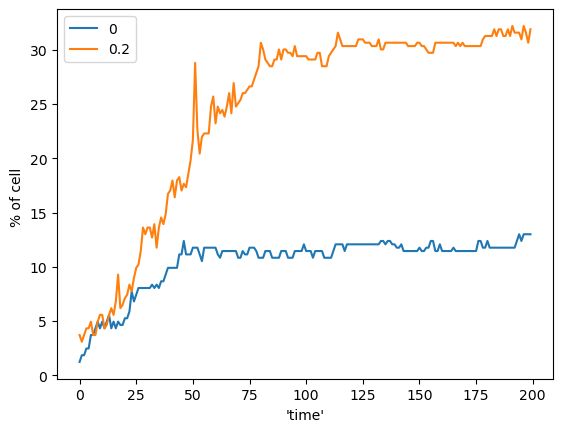

In [45]:
fig, ax = plt.subplots()
ax.plot(nb_changes, label='0')
ax.plot(nb_changes2, label='0.2')
ax.legend()
ax.set_xlabel('\'time\'')
ax.set_ylabel('% of cell ')

# fig.set_size_inches((10,10))